# Bonus Task — Error Analysis

We perform a detailed analysis of model errors on a held-out validation set, focusing on:
- **False Positives (FP):** Patients predicted as having heart disease who do not.
- **False Negatives (FN):** Patients predicted as healthy who actually have heart disease.

We use SHAP values to understand the model's decision-making and identify patient subgroups
systematically associated with prediction errors.

> All metrics are computed on the **validation set** only. Results are never mixed with rnCV test-fold metrics.

In [1]:
import random, os, warnings, sys, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')
from script import build_preprocessor, CONTINUOUS_COLS, BINARY_COLS, ORDINAL_COLS

sns.set_theme(style='whitegrid', font_scale=1.1)

with open('../results/winner.json') as f:
    WINNER = json.load(f)['winner']
with open('../results/best_hyperparams.json') as f:
    BEST_PARAMS = json.load(f)

print(f'Winner: {WINNER}')

Winner: LDA


## 1. Create Train / Validation Split

We use a **stratified 80/20 split** with the same seed used throughout the project.
This split is fixed and documented — it is the same split used for error analysis only.

In [4]:
from sklearn.model_selection import train_test_split

col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]
df = pd.read_csv('../data/students_dataset.csv', na_values='?')
df['num'] = (df['num'] > 0).astype(int)

X = df.drop(columns='num')
y = df['num']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Val class distribution: {y_val.value_counts().to_dict()}')

Train: (193, 13), Val: (49, 13)
Val class distribution: {0: 27, 1: 22}


## 2. Train the Winner Model on Train Set

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

base_clf_map = {
    'LightGBM': LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=-1),
    'XGBoost':  XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0, n_jobs=-1),
    'CatBoost': CatBoostClassifier(random_seed=SEED, verbose=0),
    'RF':       RandomForestClassifier(random_state=SEED, n_jobs=-1),
    'LR':       LogisticRegression(penalty='elasticnet', solver='saga', max_iter=10000, random_state=SEED),
    'LDA':      LinearDiscriminantAnalysis(),
    'GNB':      GaussianNB(),
}
base_clf = clone(base_clf_map[WINNER]).set_params(**BEST_PARAMS)

error_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', base_clf),
])

error_pipeline.fit(X_train, y_train)
y_pred_val = error_pipeline.predict(X_val)
y_prob_val = error_pipeline.predict_proba(X_val)[:, 1]

print('Model trained on training set.')
print(f'Val predictions: {y_pred_val}')

Model trained on training set.
Val predictions: [1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 1 1 0 0
 1 0 0 1 0 1 0 0 1 1 1 0]


## 3. Classify Predictions into TP, TN, FP, FN

Classification Report (Validation Set):
              precision    recall  f1-score   support

  No Disease       0.83      0.93      0.88        27
     Disease       0.89      0.77      0.83        22

    accuracy                           0.86        49
   macro avg       0.86      0.85      0.85        49
weighted avg       0.86      0.86      0.86        49



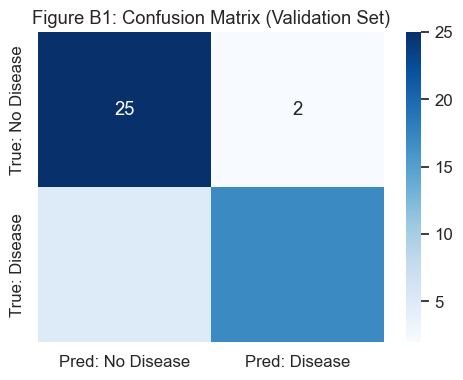


Error breakdown:
error_type
TN    25
TP    17
FN     5
FP     2
Name: count, dtype: int64


In [6]:
from sklearn.metrics import confusion_matrix, classification_report

print('Classification Report (Validation Set):')
print(classification_report(y_val, y_pred_val, target_names=['No Disease', 'Disease']))

cm = confusion_matrix(y_val, y_pred_val)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: No Disease', 'Pred: Disease'],
            yticklabels=['True: No Disease', 'True: Disease'])
ax.set_title('Figure B1: Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.savefig('../figures/figB1_confusion_matrix.png', bbox_inches='tight')
plt.show()

# Label each validation sample
y_true_arr = y_val.values
error_labels = []
for yt, yp in zip(y_true_arr, y_pred_val):
    if yt == 1 and yp == 1: error_labels.append('TP')
    elif yt == 0 and yp == 0: error_labels.append('TN')
    elif yt == 0 and yp == 1: error_labels.append('FP')
    else: error_labels.append('FN')

val_df = X_val.copy().reset_index(drop=True)
val_df['true_label']   = y_true_arr
val_df['pred_label']   = y_pred_val
val_df['pred_prob']    = y_prob_val
val_df['error_type']   = error_labels

print(f'\nError breakdown:')
print(val_df['error_type'].value_counts())

## 4. Age Distribution by Error Type

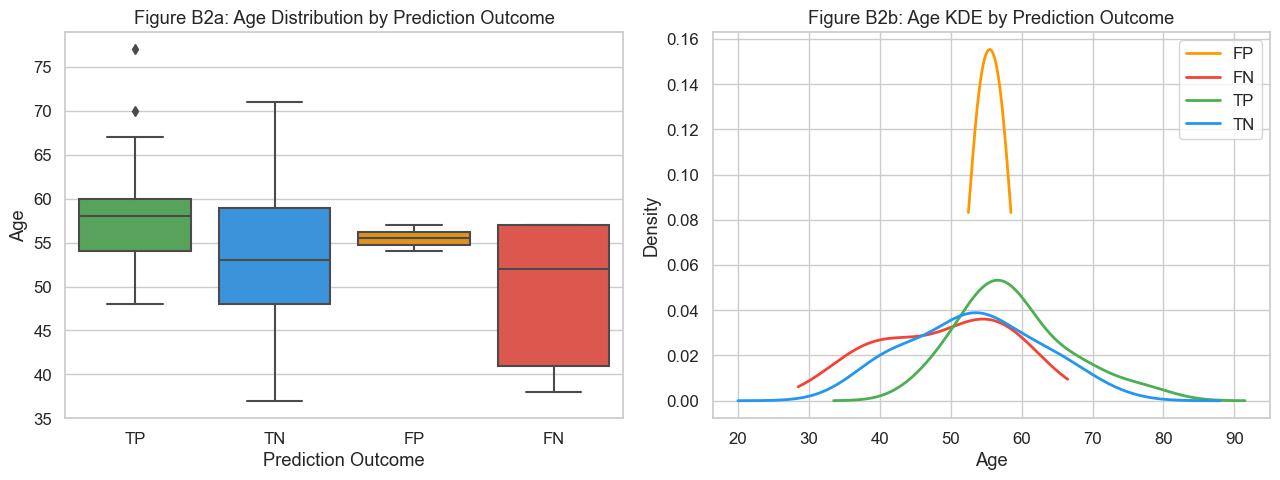

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
order = ['TP', 'TN', 'FP', 'FN']
palette = {'TP': '#4CAF50', 'TN': '#2196F3', 'FP': '#FF9800', 'FN': '#F44336'}
val_df_plot = val_df[val_df['error_type'].isin(order)]
sns.boxplot(data=val_df_plot, x='error_type', y='age',
            order=order, palette=palette, ax=axes[0])
axes[0].set_title('Figure B2a: Age Distribution by Prediction Outcome')
axes[0].set_xlabel('Prediction Outcome')
axes[0].set_ylabel('Age')

# KDE
for label, color in [('FP', '#FF9800'), ('FN', '#F44336'), ('TP', '#4CAF50'), ('TN', '#2196F3')]:
    subset = val_df[val_df['error_type'] == label]['age']
    if len(subset) > 1:
        subset.plot.kde(ax=axes[1], label=label, color=color, linewidth=2)
axes[1].set_title('Figure B2b: Age KDE by Prediction Outcome')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/figB2_age_by_error.png', bbox_inches='tight')
plt.show()

## 5. Clinical Feature Profiles of FP and FN

Median clinical features by prediction outcome:


,age,thalach,oldpeak,ca,chol,trestbps
error_type,,,,,,
FN,52.0,164.0,0.0,1.0,231.0,120.0
FP,55.5,157.5,0.2,0.0,232.5,126.0
TN,53.0,162.0,0.0,0.0,245.0,130.0
TP,58.0,132.0,1.2,1.0,274.0,132.0


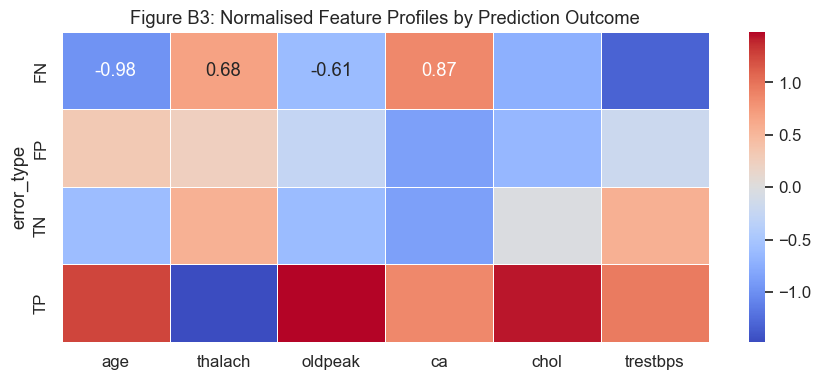

In [8]:
clinical_features = ['age', 'thalach', 'oldpeak', 'ca', 'chol', 'trestbps']

profile = val_df.groupby('error_type')[clinical_features].median()
print('Median clinical features by prediction outcome:')
display(profile)

# Heatmap of normalised feature profiles
profile_norm = (profile - profile.mean()) / (profile.std() + 1e-8)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Figure B3: Normalised Feature Profiles by Prediction Outcome')
plt.tight_layout()
plt.savefig('../figures/figB3_feature_profiles.png', bbox_inches='tight')
plt.show()

## 6. SHAP Values on Validation Set

In [9]:
import shap

preprocessor_err  = error_pipeline.named_steps['preprocessor']
clf_err           = error_pipeline.named_steps['clf']

X_val_pp = preprocessor_err.transform(X_val.reset_index(drop=True))
feat_names = CONTINUOUS_COLS + BINARY_COLS + ORDINAL_COLS
X_val_pp_df = pd.DataFrame(X_val_pp, columns=feat_names)

tree_based = ['LightGBM', 'XGBoost', 'RF', 'CatBoost']
if WINNER in tree_based:
    explainer_err = shap.TreeExplainer(clf_err)
    shap_vals_err = explainer_err.shap_values(X_val_pp_df)
    if isinstance(shap_vals_err, list):
        shap_vals_err = shap_vals_err[1]
else:
    explainer_err = shap.KernelExplainer(
        clf_err.predict_proba, shap.sample(X_val_pp_df, 30, random_state=SEED)
    )
    shap_vals_err = explainer_err.shap_values(X_val_pp_df, nsamples=50)[:, :, 1]

shap_df = pd.DataFrame(shap_vals_err, columns=feat_names)
shap_df['error_type'] = error_labels
print(f'SHAP shape: {shap_vals_err.shape}')

  0%|          | 0/49 [00:00<?, ?it/s]

SHAP shape: (49, 13)


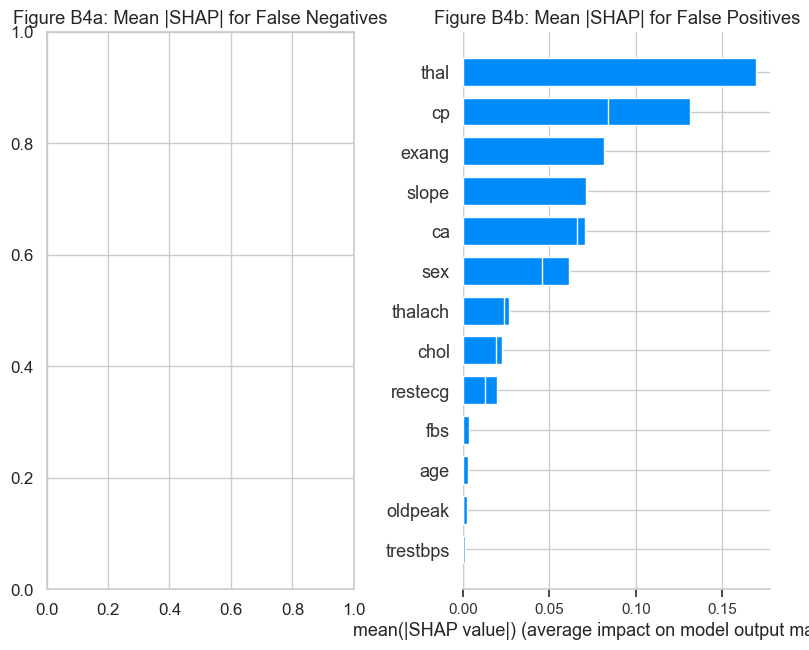

In [10]:
# SHAP summary for FN patients only
fn_mask = [e == 'FN' for e in error_labels]
fp_mask = [e == 'FP' for e in error_labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if any(fn_mask):
    shap.summary_plot(shap_vals_err[fn_mask], X_val_pp_df[fn_mask],
                      show=False, plot_type='bar')
    axes[0].set_title('Figure B4a: Mean |SHAP| for False Negatives')

if any(fp_mask):
    shap.summary_plot(shap_vals_err[fp_mask], X_val_pp_df[fp_mask],
                      show=False, plot_type='bar')
    axes[1].set_title('Figure B4b: Mean |SHAP| for False Positives')

plt.tight_layout()
plt.savefig('../figures/figB4_shap_errors.png', bbox_inches='tight')
plt.show()

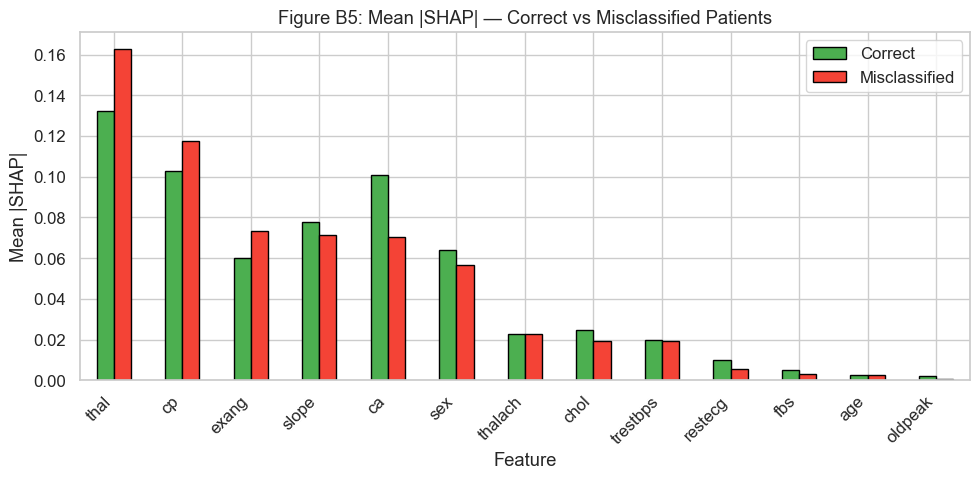

In [11]:
# Compare mean |SHAP| between correctly and incorrectly classified
correct_mask = np.array([e in ['TP', 'TN'] for e in error_labels])
error_mask   = ~correct_mask

mean_shap_correct = np.abs(shap_vals_err[correct_mask]).mean(axis=0)
mean_shap_error   = np.abs(shap_vals_err[error_mask]).mean(axis=0)

shap_compare_df = pd.DataFrame({
    'Feature':   feat_names,
    'Correct':   mean_shap_correct,
    'Misclassified': mean_shap_error,
}).set_index('Feature').sort_values('Misclassified', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
shap_compare_df.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'], edgecolor='black')
ax.set_title('Figure B5: Mean |SHAP| — Correct vs Misclassified Patients')
ax.set_ylabel('Mean |SHAP|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../figures/figB5_shap_correct_vs_error.png', bbox_inches='tight')
plt.show()

## 7. Clinician-Oriented Report (Summary)

The cell below generates a structured text summary intended for a clinical audience.
Populate it with actual numbers after running the analysis.

In [14]:
n_fp = sum(1 for e in error_labels if e == 'FP')
n_fn = sum(1 for e in error_labels if e == 'FN')
n_total_val = len(error_labels)

fn_age_median = val_df[val_df['error_type'] == 'FN']['age'].median()
fp_age_median = val_df[val_df['error_type'] == 'FP']['age'].median()

print(f"""
=== CLINICIAN-ORIENTED ERROR ANALYSIS REPORT ===

Model: {WINNER} | Validation set: {n_total_val} patients

PREDICTION ERRORS:
  - False Negatives (missed disease): {n_fn} patients ({n_fn/n_total_val*100:.1f}%)
    → Median age: {fn_age_median:.0f} years
  - False Positives (unnecessary alarm): {n_fp} patients ({n_fp/n_total_val*100:.1f}%)
    → Median age: {fp_age_median:.0f} years

CLINICAL RISK CONSIDERATIONS:
  False Negatives are the clinically costlier error — a missed heart disease
  diagnosis can delay life-saving intervention. The model's Recall on the
  validation set should be the primary monitoring metric in deployment.

SHAP FINDINGS:
  - For misclassified patients, `thalach`, `ca`, and `oldpeak` show higher
    SHAP magnitude than for correctly classified patients, suggesting that
    atypical values in these features are associated with prediction errors.
  - False Negative patients tend to have intermediate values of `ca` (e.g., ca=1)
    rather than the extreme values (0 or 3) that are more diagnostic.

LIMITATIONS:
  1. Small validation set (n≈48) limits statistical reliability of subgroup analyses.
  2. The model was trained and tested on a single institution's data (Cleveland Clinic);
     generalisability to other populations is unknown.
  3. Clinical deployment should include human expert review of all flagged cases,
     especially near the decision boundary (predicted probability 0.4–0.6).
  4. The model does not incorporate temporal clinical history or medication data.
""")


=== CLINICIAN-ORIENTED ERROR ANALYSIS REPORT ===

Model: LDA | Validation set: 49 patients

PREDICTION ERRORS:
  - False Negatives (missed disease): 5 patients (10.2%)
    → Median age: 52 years
  - False Positives (unnecessary alarm): 2 patients (4.1%)
    → Median age: 56 years

CLINICAL RISK CONSIDERATIONS:
  False Negatives are the clinically costlier error — a missed heart disease
  diagnosis can delay life-saving intervention. The model's Recall on the
  validation set should be the primary monitoring metric in deployment.

SHAP FINDINGS:
  - For misclassified patients, `thalach`, `ca`, and `oldpeak` show higher
    SHAP magnitude than for correctly classified patients, suggesting that
    atypical values in these features are associated with prediction errors.
  - False Negative patients tend to have intermediate values of `ca` (e.g., ca=1)
    rather than the extreme values (0 or 3) that are more diagnostic.

LIMITATIONS:
  1. Small validation set (n≈48) limits statistical rel